# Task 1.1: Application of Python-based geospatial visualisation tool (e.g., GeoPandas) on a real- world dataset 

In [248]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

In [249]:
refugee = pd.read_csv("data/persons_of_concern_demographics.csv")


In [250]:
refugee.head()

,Year,Country of Asylum,Country of Origin,Country of Asylum ISO,Country of Origin ISO,Female 0 - 4,Female 5 - 11,Female 12 - 17,Female 18 - 59,Female 60+,Female Other,Female Total,Male 0 - 4,Male 5 - 11,Male 12 - 17,Male 18 - 59,Male 60+,Male Other,Male Total,Total
0,2001,-,Afghanistan,-,AFG,192279,304463,260994,582552,40557,6717,1387562,195602,323327,277122,785010,57395,8854,1647310,5140545
1,2001,-,Iran (Islamic Rep. of),-,IRN,1721,2794,2440,6352,458,1330,15095,1767,2961,2560,7830,560,2122,17800,106628
2,2001,-,Iraq,-,IRQ,2488,20261,17390,127005,11755,1789,180688,2501,21658,18542,185983,10963,2710,242357,578334
3,2001,-,North Macedonia,-,MKD,1019,2088,1805,8080,1383,74,14449,1159,2234,1933,7255,1190,86,13857,30788
4,2001,-,Serbia and Kosovo: S/RES/1244 (1999),-,SRB,8657,15563,13329,65421,17376,7864,128210,9303,16535,14165,65563,13779,9573,128918,543654


In [251]:
refugee.columns

Index(['Year', 'Country of Asylum', 'Country of Origin',
       'Country of Asylum ISO', 'Country of Origin ISO', 'Female 0 - 4',
       'Female 5 - 11', 'Female 12 - 17', 'Female 18 - 59', 'Female 60+',
       'Female Other', 'Female Total', 'Male 0 - 4', 'Male 5 - 11',
       'Male 12 - 17', 'Male 18 - 59', 'Male 60+', 'Male Other', 'Male Total',
       'Total'],
      dtype='str')

In [252]:
refugee.describe()


,Year,Female 0 - 4,Female 5 - 11,Female 12 - 17,Female 18 - 59,Female 60+,Female Other,Female Total,Male 0 - 4,Male 5 - 11,Male 12 - 17,Male 18 - 59,Male 60+,Male Other,Male Total,Total
count,4661.000000,4661.000000,4.661000e+03,4.661000e+03,4.661000e+03,4661.000000,4.661000e+03,4.661000e+03,4661.000000,4.661000e+03,4.661000e+03,4.661000e+03,4661.000000,4.661000e+03,4.661000e+03,4.661000e+03
mean,2012.732246,7944.582278,1.166187e+04,8.662124e+03,2.972893e+04,3544.249517,2.198520e+04,8.352696e+04,8072.672602,1.201343e+04,9.112376e+03,2.958149e+04,3177.455911,2.140380e+04,8.336123e+04,2.780156e+05
std,6.943670,47612.449305,6.817692e+04,4.977553e+04,1.714929e+05,28063.598895,1.841374e+05,4.128308e+05,48377.248303,7.049394e+04,5.160432e+04,1.652293e+05,23373.433865,1.740902e+05,4.032877e+05,1.319654e+06
min,2001.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,5.000000e+00
25%,2007.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,7.000000e+00,0.000000,0.000000e+00,0.000000e+00,5.000000e+00,0.000000,0.000000e+00,9.000000e+00,1.760000e+02
50%,2013.000000,5.000000,8.000000e+00,8.000000e+00,4.800000e+01,0.000000,1.600000e+01,1.580000e+02,5.000000,8.000000e+00,8.000000e+00,7.700000e+01,0.000000,2.100000e+01,2.080000e+02,2.112000e+03
75%,2019.000000,144.000000,2.320000e+02,1.880000e+02,1.262000e+03,82.000000,3.440000e+02,4.067000e+03,143.000000,2.440000e+02,2.200000e+02,1.951000e+03,97.000000,6.050000e+02,5.643000e+03,3.446300e+04
max,2024.000000,878613.000000,1.660594e+06,1.096779e+06,3.182316e+06,837457.000000,4.323970e+06,7.220071e+06,895400.000000,1.682751e+06,1.116633e+06,2.704253e+06,680577.000000,4.087720e+06,7.092986e+06,3.000298e+07


In [253]:
print("Total raws:", refugee.shape[0])

Total raws: 4661


In [254]:
refugee.duplicated().sum()

np.int64(0)

In [300]:
refugee.isna().sum()

Year                     0
Country of Asylum        0
Country of Origin        0
Country of Asylum ISO    0
Country of Origin ISO    0
Female 0 - 4             0
Female 5 - 11            0
Female 12 - 17           0
Female 18 - 59           0
Female 60+               0
Female Other             0
Female Total             0
Male 0 - 4               0
Male 5 - 11              0
Male 12 - 17             0
Male 18 - 59             0
Male 60+                 0
Male Other               0
Male Total               0
Total                    0
dtype: int64

In [256]:
refugee_2004 = refugee[refugee['Year'] == 2004]
refugee_2024 = refugee[refugee['Year'] == 2024]

In [301]:
refugee_2004.head()

,Year,Country of Asylum,Country of Origin,Country of Asylum ISO,Country of Origin ISO,Female 0 - 4,Female 5 - 11,Female 12 - 17,Female 18 - 59,Female 60+,Female Other,Female Total,Male 0 - 4,Male 5 - 11,Male 12 - 17,Male 18 - 59,Male 60+,Male Other,Male Total,Total
562,2004,-,Afghanistan,-,AFG,110737,157553,236182,401876,32141,456,938945,111036,160531,248601,436368,37697,571,994804,2691054
563,2004,-,Iran (Islamic Rep. of),-,IRN,210,586,480,2335,103,351,4065,250,694,576,3616,131,490,5757,124690
564,2004,-,Iraq,-,IRQ,4053,7595,15596,30732,2435,1081,61492,4318,8352,16870,50035,2486,1319,83380,358647
565,2004,-,North Macedonia,-,MKD,64,85,67,253,25,20,514,60,91,90,188,39,39,507,5801
566,2004,-,Serbia and Kosovo: S/RES/1244 (1999),-,SRB,3580,16264,13946,68318,19415,51970,173493,3962,17342,14867,67869,15570,56250,175860,579815


In [258]:
countries = gpd.read_file(r"C:\Users\Jamal Amro\Geo_Spatial_Env\workshop5 week6\ne_110m_admin_0_countries.shp")

In [259]:
countries.head()

,featurecla,scalerank,LABELRANK,SOVEREIGNT,SOV_A3,ADM0_DIF,LEVEL,TYPE,TLC,ADMIN,...,FCLASS_TR,FCLASS_ID,FCLASS_PL,FCLASS_GR,FCLASS_IT,FCLASS_NL,FCLASS_SE,FCLASS_BD,FCLASS_UA,geometry
0,Admin-0 country,1,6,Fiji,FJI,0,2,Sovereign country,1,Fiji,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"MULTIPOLYGON (((180 -16.06713, 180 -16.55522, ..."
1,Admin-0 country,1,3,United Republic of Tanzania,TZA,0,2,Sovereign country,1,United Republic of Tanzania,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"POLYGON ((33.90371 -0.95, 34.07262 -1.05982, 3..."
2,Admin-0 country,1,7,Western Sahara,SAH,0,2,Indeterminate,1,Western Sahara,...,Unrecognized,Unrecognized,Unrecognized,NaN,NaN,Unrecognized,NaN,NaN,NaN,"POLYGON ((-8.66559 27.65643, -8.66512 27.58948..."
3,Admin-0 country,1,2,Canada,CAN,0,2,Sovereign country,1,Canada,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"MULTIPOLYGON (((-122.84 49, -122.97421 49.0025..."
4,Admin-0 country,1,2,United States of America,US1,1,2,Country,1,United States of America,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"MULTIPOLYGON (((-122.84 49, -120 49, -117.0312..."


In [303]:
list(countries.columns)

['featurecla',
 'scalerank',
 'LABELRANK',
 'SOVEREIGNT',
 'SOV_A3',
 'ADM0_DIF',
 'LEVEL',
 'TYPE',
 'TLC',
 'ADMIN',
 'ADM0_A3',
 'GEOU_DIF',
 'GEOUNIT',
 'GU_A3',
 'SU_DIF',
 'SUBUNIT',
 'SU_A3',
 'BRK_DIFF',
 'NAME',
 'NAME_LONG',
 'BRK_A3',
 'BRK_NAME',
 'BRK_GROUP',
 'ABBREV',
 'POSTAL',
 'FORMAL_EN',
 'FORMAL_FR',
 'NAME_CIAWF',
 'NOTE_ADM0',
 'NOTE_BRK',
 'NAME_SORT',
 'NAME_ALT',
 'MAPCOLOR7',
 'MAPCOLOR8',
 'MAPCOLOR9',
 'MAPCOLOR13',
 'POP_EST',
 'POP_RANK',
 'POP_YEAR',
 'GDP_MD',
 'GDP_YEAR',
 'ECONOMY',
 'INCOME_GRP',
 'FIPS_10',
 'ISO_A2',
 'ISO_A2_EH',
 'ISO_A3',
 'ISO_A3_EH',
 'ISO_N3',
 'ISO_N3_EH',
 'UN_A3',
 'WB_A2',
 'WB_A3',
 'WOE_ID',
 'WOE_ID_EH',
 'WOE_NOTE',
 'ADM0_ISO',
 'ADM0_DIFF',
 'ADM0_TLC',
 'ADM0_A3_US',
 'ADM0_A3_FR',
 'ADM0_A3_RU',
 'ADM0_A3_ES',
 'ADM0_A3_CN',
 'ADM0_A3_TW',
 'ADM0_A3_IN',
 'ADM0_A3_NP',
 'ADM0_A3_PK',
 'ADM0_A3_DE',
 'ADM0_A3_GB',
 'ADM0_A3_BR',
 'ADM0_A3_IL',
 'ADM0_A3_PS',
 'ADM0_A3_SA',
 'ADM0_A3_EG',
 'ADM0_A3_MA',
 'ADM0_A3_PT

In [261]:
map_2004 = countries.merge(
    refugee_2004,
    left_on='ISO_A3',
    right_on='Country of Origin ISO',
    how='left'
)

In [262]:
map_2004.head()

,featurecla,scalerank,LABELRANK,SOVEREIGNT,SOV_A3,ADM0_DIF,LEVEL,TYPE,TLC,ADMIN,...,Female Other,Female Total,Male 0 - 4,Male 5 - 11,Male 12 - 17,Male 18 - 59,Male 60+,Male Other,Male Total,Total
0,Admin-0 country,1,6,Fiji,FJI,0,2,Sovereign country,1,Fiji,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1800.0
1,Admin-0 country,1,3,United Republic of Tanzania,TZA,0,2,Sovereign country,1,United Republic of Tanzania,...,0.0,10.0,0.0,5.0,0.0,42.0,0.0,0.0,47.0,5321.0
2,Admin-0 country,1,7,Western Sahara,SAH,0,2,Indeterminate,1,Western Sahara,...,13780.0,89894.0,14502.0,16337.0,14004.0,24918.0,10274.0,12229.0,92264.0,191741.0
3,Admin-0 country,1,2,Canada,CAN,0,2,Sovereign country,1,Canada,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,75.0
4,Admin-0 country,1,2,United States of America,US1,1,2,Country,1,United States of America,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,717.0


In [263]:
map_2024 = countries.merge(
    refugee_2024,
    left_on='ISO_A3',
    right_on='Country of Origin ISO',
    how='left'
)

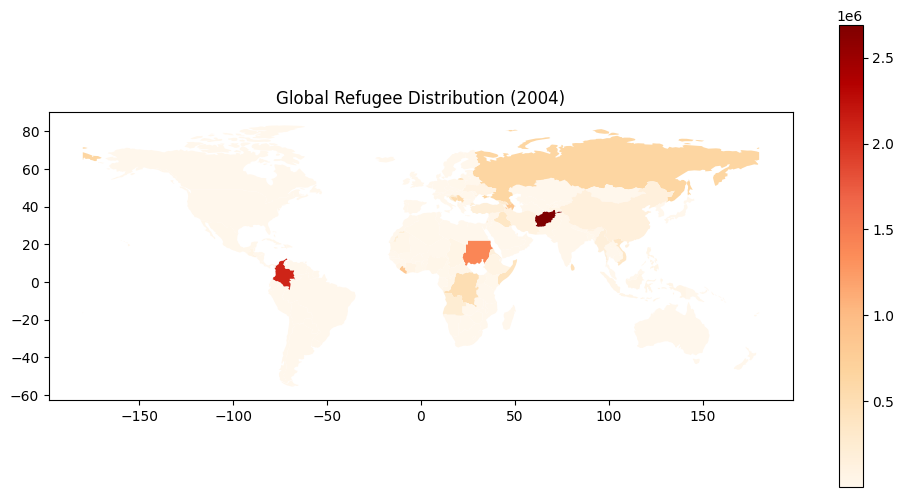

In [264]:
map_2004.plot(
    column='Total',
    cmap='OrRd',
    legend=True,
    figsize=(12,6)
)

plt.title("Global Refugee Distribution (2004)")
plt.show()

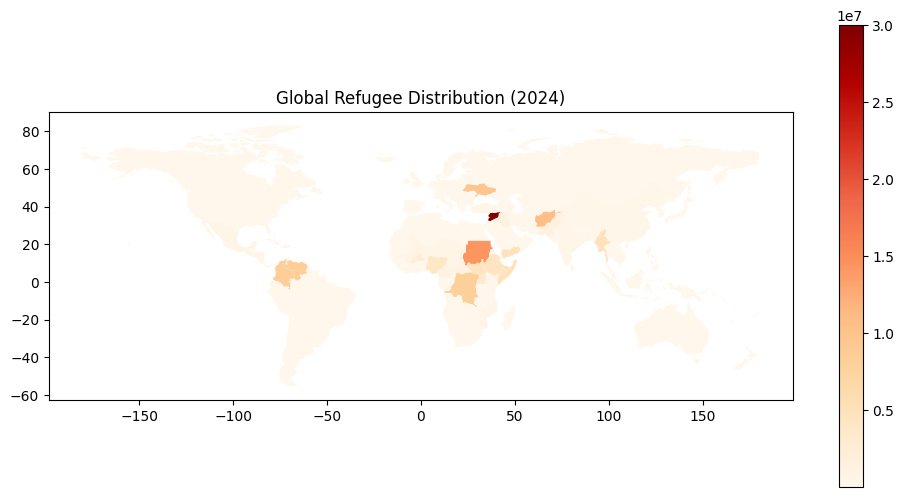

In [265]:
map_2024.plot(
    column='Total',
    cmap='OrRd',
    legend=True,
    figsize=(12,6)
)

plt.title("Global Refugee Distribution (2024)")
plt.show()

In [266]:
map_2004['Total'].describe()

count    1.590000e+02
mean     9.972551e+04
std      3.198932e+05
min      5.000000e+00
25%      4.060000e+02
50%      2.970000e+03
75%      3.441700e+04
max      2.691054e+06
Name: Total, dtype: float64

In [267]:
countries[['ADMIN','SOV_A3']].head(10)

,ADMIN,SOV_A3
0,Fiji,FJI
1,United Republic of Tanzania,TZA
2,Western Sahara,SAH
3,Canada,CAN
4,United States of America,US1
5,Kazakhstan,KA1
6,Uzbekistan,UZB
7,Papua New Guinea,PNG
8,Indonesia,IDN
9,Argentina,ARG


<Axes: title={'center': 'Top 10 Countries by Refugee Numbers (2004)'}, xlabel='ADMIN'>

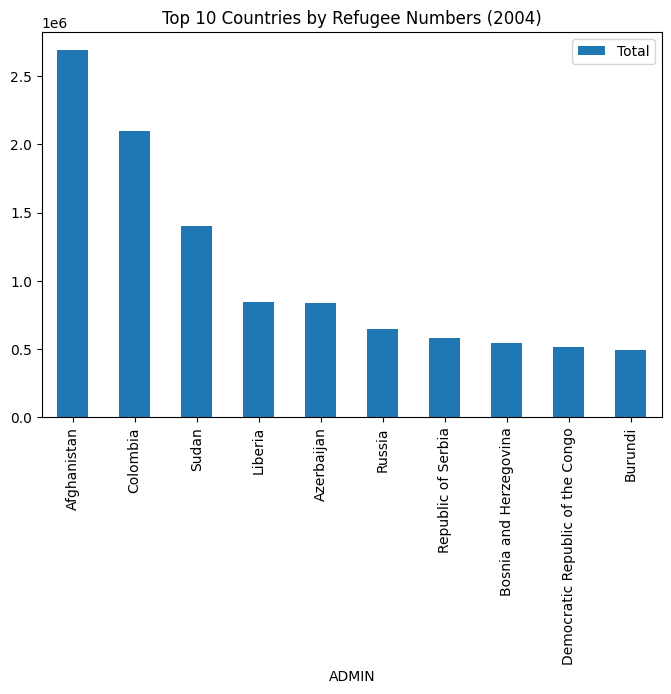

In [268]:
map_2004.sort_values(by='Total', ascending=False).head(10).plot(
    x='ADMIN',
    y='Total',
    kind='bar',
    figsize=(8,5),
    title='Top 10 Countries by Refugee Numbers (2004)'
)


# Inference 1 (2004)

## The bar chart for 2004 shows that Afghanistan had the highest number of refugees, followed by Colombia and Sudan. This indicates that during this period, refugee movements were strongly influenced by regi=onal conflicts and political instability in these countries. The distribution also shows that a relatively small number of countries accounted for a large share of global refugee populations.

<Axes: title={'center': 'Top 10 Countries by Refugee Numbers (2004)'}, xlabel='ADMIN'>

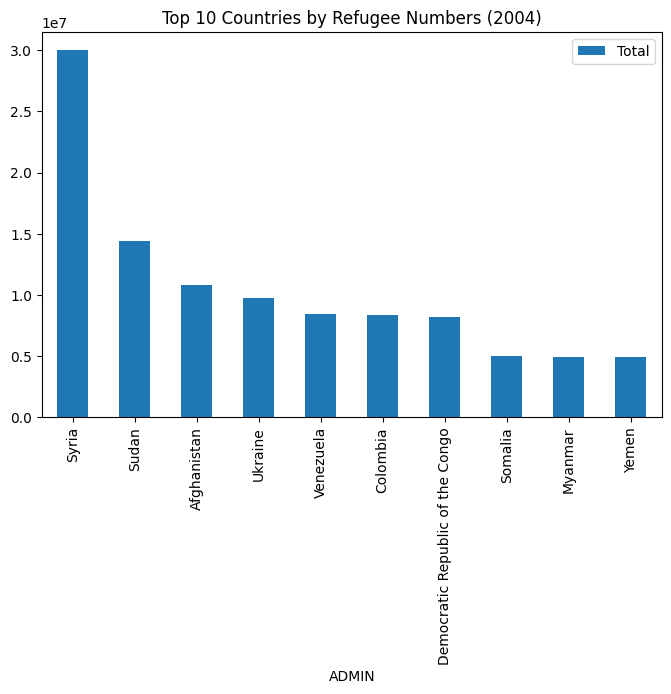

In [269]:
map_2024.sort_values(by='Total', ascending=False).head(10).plot(
    x='ADMIN',
    y='Total',
    kind='bar',
    figsize=(8,5),
    title='Top 10 Countries by Refugee Numbers (2004)'
)


# Inference 2 (2024)

## The chart for 2024 shows a significant shift in refugee patterns, with Syria having the highest refugee numbers, followed by Sudan and Afghanistan. This reflects the impact of more recent conflicts and humanitarian crises, particularly the Syrian civil war and ongoing instability in several regions. The results highlight how refugee distribution changes over time due to evolving geopolitical and social conditions.

# Task 1.2: Analysis of geospatial datasets 

In [271]:
conflict = pd.read_csv("data/GEDEvent_v25_1.csv")
conflict.head()



C:\Users\Jamal Amro\AppData\Local\Temp\ipykernel_25120\3209839319.py:1: DtypeWarning: Columns (0: gwnoa) have mixed types. Specify dtype option on import or set low_memory=False.
  conflict = pd.read_csv("data/GEDEvent_v25_1.csv")


,id,relid,year,active_year,code_status,type_of_violence,conflict_dset_id,conflict_new_id,conflict_name,dyad_dset_id,...,date_end,deaths_a,deaths_b,deaths_civilians,deaths_unknown,best,high,low,gwnoa,gwnob
0,244657,IRQ-2017-1-524-322,2017,True,Clear,1,259,259,Iraq: Government,524,...,2017-07-31 00:00:00.000,0,4,0,2,6,6,6,645,NaN
1,412700,IRQ-2021-1-524-145,2021,True,Clear,1,259,259,Iraq: Government,524,...,2021-08-26 00:00:00.000,13,1,141,28,183,184,171,645,NaN
2,413023,IRQ-2021-1-524-143,2021,True,Clear,1,259,259,Iraq: Government,524,...,2021-08-28 00:00:00.000,0,2,0,0,2,3,0,645,NaN
3,412909,IRQ-2021-1-524-144,2021,True,Clear,1,259,259,Iraq: Government,524,...,2021-08-29 00:00:00.000,0,0,10,0,10,10,9,645,NaN
4,132140,AFG-1989-1-411-2,1989,True,Clear,1,333,333,Afghanistan: Government,724,...,1989-01-13 00:00:00.000,6,0,0,0,6,6,6,700,NaN


In [272]:
countries.head()

,featurecla,scalerank,LABELRANK,SOVEREIGNT,SOV_A3,ADM0_DIF,LEVEL,TYPE,TLC,ADMIN,...,FCLASS_TR,FCLASS_ID,FCLASS_PL,FCLASS_GR,FCLASS_IT,FCLASS_NL,FCLASS_SE,FCLASS_BD,FCLASS_UA,geometry
0,Admin-0 country,1,6,Fiji,FJI,0,2,Sovereign country,1,Fiji,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"MULTIPOLYGON (((180 -16.06713, 180 -16.55522, ..."
1,Admin-0 country,1,3,United Republic of Tanzania,TZA,0,2,Sovereign country,1,United Republic of Tanzania,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"POLYGON ((33.90371 -0.95, 34.07262 -1.05982, 3..."
2,Admin-0 country,1,7,Western Sahara,SAH,0,2,Indeterminate,1,Western Sahara,...,Unrecognized,Unrecognized,Unrecognized,NaN,NaN,Unrecognized,NaN,NaN,NaN,"POLYGON ((-8.66559 27.65643, -8.66512 27.58948..."
3,Admin-0 country,1,2,Canada,CAN,0,2,Sovereign country,1,Canada,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"MULTIPOLYGON (((-122.84 49, -122.97421 49.0025..."
4,Admin-0 country,1,2,United States of America,US1,1,2,Country,1,United States of America,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"MULTIPOLYGON (((-122.84 49, -120 49, -117.0312..."


In [273]:
conflict.info()

<class 'pandas.DataFrame'>
RangeIndex: 385918 entries, 0 to 385917
Data columns (total 49 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 385918 non-null  int64  
 1   relid              385918 non-null  str    
 2   year               385918 non-null  int64  
 3   active_year        385918 non-null  bool   
 4   code_status        385918 non-null  str    
 5   type_of_violence   385918 non-null  int64  
 6   conflict_dset_id   385918 non-null  int64  
 7   conflict_new_id    385918 non-null  int64  
 8   conflict_name      385918 non-null  str    
 9   dyad_dset_id       385918 non-null  int64  
 10  dyad_new_id        385918 non-null  int64  
 11  dyad_name          385918 non-null  str    
 12  side_a_dset_id     385918 non-null  int64  
 13  side_a_new_id      385918 non-null  int64  
 14  side_a             385918 non-null  str    
 15  side_b_dset_id     385918 non-null  int64  
 16  side_b_new_id

In [274]:
conflict.columns

Index(['id', 'relid', 'year', 'active_year', 'code_status', 'type_of_violence',
       'conflict_dset_id', 'conflict_new_id', 'conflict_name', 'dyad_dset_id',
       'dyad_new_id', 'dyad_name', 'side_a_dset_id', 'side_a_new_id', 'side_a',
       'side_b_dset_id', 'side_b_new_id', 'side_b', 'number_of_sources',
       'source_article', 'source_office', 'source_date', 'source_headline',
       'source_original', 'where_prec', 'where_coordinates',
       'where_description', 'adm_1', 'adm_2', 'latitude', 'longitude',
       'geom_wkt', 'priogrid_gid', 'country', 'country_id', 'region',
       'event_clarity', 'date_prec', 'date_start', 'date_end', 'deaths_a',
       'deaths_b', 'deaths_civilians', 'deaths_unknown', 'best', 'high', 'low',
       'gwnoa', 'gwnob'],
      dtype='str')

In [275]:
refugee.columns

Index(['Year', 'Country of Asylum', 'Country of Origin',
       'Country of Asylum ISO', 'Country of Origin ISO', 'Female 0 - 4',
       'Female 5 - 11', 'Female 12 - 17', 'Female 18 - 59', 'Female 60+',
       'Female Other', 'Female Total', 'Male 0 - 4', 'Male 5 - 11',
       'Male 12 - 17', 'Male 18 - 59', 'Male 60+', 'Male Other', 'Male Total',
       'Total'],
      dtype='str')

In [276]:
countries.columns

Index(['featurecla', 'scalerank', 'LABELRANK', 'SOVEREIGNT', 'SOV_A3',
       'ADM0_DIF', 'LEVEL', 'TYPE', 'TLC', 'ADMIN',
       ...
       'FCLASS_TR', 'FCLASS_ID', 'FCLASS_PL', 'FCLASS_GR', 'FCLASS_IT',
       'FCLASS_NL', 'FCLASS_SE', 'FCLASS_BD', 'FCLASS_UA', 'geometry'],
      dtype='str', length=169)

In [277]:
refugee.shape

(4661, 20)

In [278]:
conflict.shape

(385918, 49)

In [279]:
conflict['year'].unique()

array([2017, 2021, 1989, 1990, 1991, 1992, 1996, 1993, 1994, 1995, 2002,
       2003, 2006, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2016, 2004,
       2005, 2007, 2015, 2018, 2019, 2020, 1997, 1998, 1999, 2000, 2001,
       2022, 2023, 2024])

In [280]:
conflict_small = conflict[['country','year','best','region']]
conflict_small.head()

,country,year,best,region
0,Afghanistan,2017,6,Asia
1,Afghanistan,2021,183,Asia
2,Afghanistan,2021,2,Asia
3,Afghanistan,2021,10,Asia
4,Afghanistan,1989,6,Asia


## Task 1.2.1

In [281]:
conflict_2000 = conflict_small[conflict_small['year'] >= 2000]

conflict_country = conflict_2000.groupby('country')['best'].sum().reset_index()
conflict_country.head()

,country,best
0,Afghanistan,256596
1,Algeria,7559
2,Angola,4345
3,Armenia,230
4,Australia,2


In [282]:
high_conflict = conflict_country[conflict_country['best'] > 5000]
high_conflict.head()

,country,best
0,Afghanistan,256596
1,Algeria,7559
6,Azerbaijan,8742
13,Brazil,19719
14,Burkina Faso,17223


In [283]:
refugee_2024 = refugee[refugee['Year'] == 2024]

In [284]:
## join both dataset confict and refugees

In [285]:
refugee_conflict = refugee_2024.merge(
    high_conflict,
    left_on='Country of Origin',
    right_on='country',
    how='inner'
)

In [286]:
## merge merged datasets with country shape file

In [287]:
map_data = countries.merge(
    refugee_conflict,
    left_on='ADMIN',
    right_on='Country of Origin',
    how='left'
)

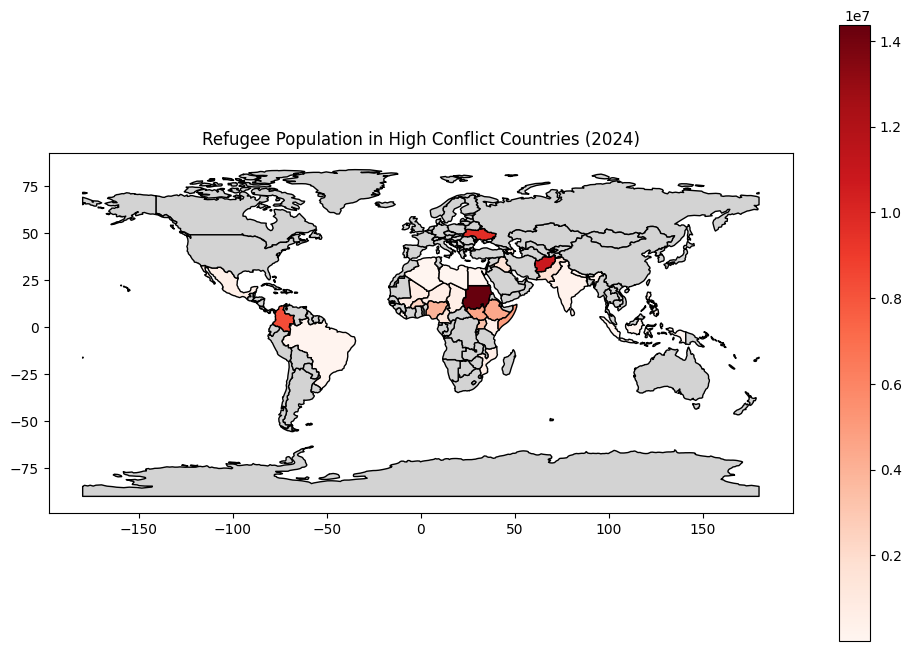

In [288]:
map_data.plot(
    column='Total',
    cmap='Reds',
    legend=True,
    figsize=(12,8),
    missing_kwds={'color':'lightgrey'},
    edgecolor='black'
)

plt.title("Refugee Population in High Conflict Countries (2024)")
plt.show()

## The choropleth map illustrates the refugee population in 2024 for countries experiencing high conflict intensity since 2000. Countries such as Sudan, Afghanistan, and Syria show the highest refugee populations, indicating that prolonged conflict has significantly contributed to large-scale displacement. Regions with lower conflict intensity display smaller refugee populations.

## Task 1.2.2

In [289]:
conflict_me = conflict_small[
    (conflict_small['region'] == 'Middle East') &
    (conflict_small['year'] == 2024)
]

In [290]:
conflict_me_agg = conflict_me.groupby('country')['best'].sum().reset_index()

In [291]:
refugee_female = refugee[
    (refugee['Year'] == 2024) &
    (refugee['Female Total'] > 50000)
]

In [292]:
conflict_refugee = conflict_me_agg.merge(
    refugee_female,
    left_on='country',
    right_on='Country of Origin',
    how='inner'
)

In [293]:
map_conflict = countries.merge(
    conflict_refugee,
    left_on='ADMIN',
    right_on='country',
    how='left'
)

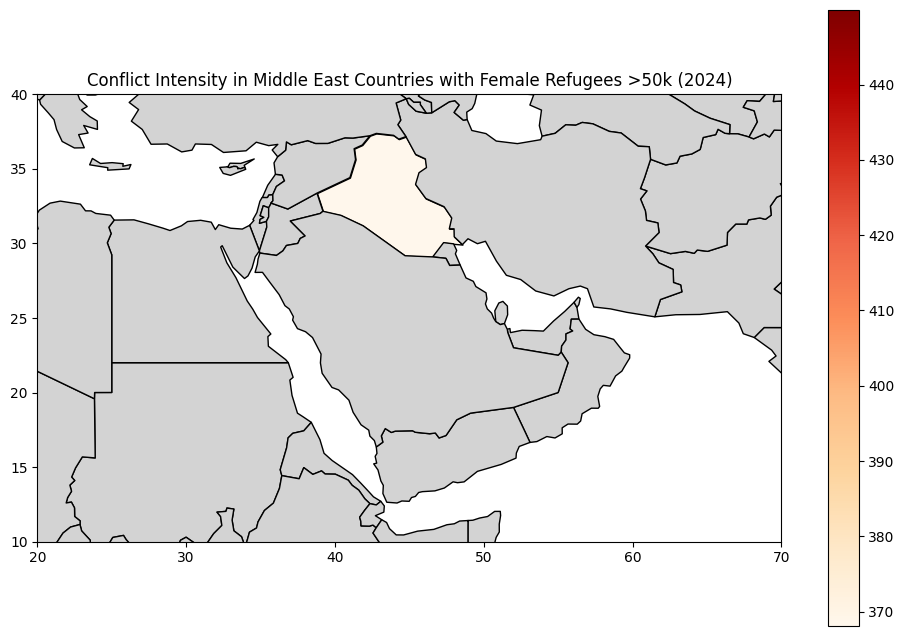

In [294]:
map_conflict.plot(
    column='best',
    cmap='OrRd',
    legend=True,
    figsize=(12,8),
    edgecolor='black',
    missing_kwds={'color':'lightgrey'}
)

plt.xlim(20,70)
plt.ylim(10,40)

plt.title("Conflict Intensity in Middle East Countries with Female Refugees >50k (2024)")
plt.show()

In [295]:
countries.columns

Index(['featurecla', 'scalerank', 'LABELRANK', 'SOVEREIGNT', 'SOV_A3',
       'ADM0_DIF', 'LEVEL', 'TYPE', 'TLC', 'ADMIN',
       ...
       'FCLASS_TR', 'FCLASS_ID', 'FCLASS_PL', 'FCLASS_GR', 'FCLASS_IT',
       'FCLASS_NL', 'FCLASS_SE', 'FCLASS_BD', 'FCLASS_UA', 'geometry'],
      dtype='str', length=169)

In [296]:
conflict.columns

Index(['id', 'relid', 'year', 'active_year', 'code_status', 'type_of_violence',
       'conflict_dset_id', 'conflict_new_id', 'conflict_name', 'dyad_dset_id',
       'dyad_new_id', 'dyad_name', 'side_a_dset_id', 'side_a_new_id', 'side_a',
       'side_b_dset_id', 'side_b_new_id', 'side_b', 'number_of_sources',
       'source_article', 'source_office', 'source_date', 'source_headline',
       'source_original', 'where_prec', 'where_coordinates',
       'where_description', 'adm_1', 'adm_2', 'latitude', 'longitude',
       'geom_wkt', 'priogrid_gid', 'country', 'country_id', 'region',
       'event_clarity', 'date_prec', 'date_start', 'date_end', 'deaths_a',
       'deaths_b', 'deaths_civilians', 'deaths_unknown', 'best', 'high', 'low',
       'gwnoa', 'gwnob'],
      dtype='str')

In [297]:
conflict_me['country'].unique()

<ArrowStringArray>
[               'Iran',                'Iraq',              'Israel',
              'Jordan',             'Lebanon',               'Syria',
              'Turkey', 'Yemen (North Yemen)']
Length: 8, dtype: str

In [298]:
countries['REGION_WB'].unique()

<ArrowStringArray>
[       'East Asia & Pacific',         'Sub-Saharan Africa',
 'Middle East & North Africa',              'North America',
      'Europe & Central Asia',  'Latin America & Caribbean',
                 'South Asia',                 'Antarctica']
Length: 8, dtype: str